# Assignment B.5 - Modern face recognition with deep learning

Have you noticed that Facebook has developed an uncanny ability to recognize your friends in your photographs? In the old days, Facebook used to make you to tag your friends in photos by clicking on them and typing in their name. Now as soon as you upload a photo, Facebook tags everyone for you like magic. This technology is called face recognition. Facebook’s algorithms are able to recognize your friends’ faces after they have been tagged only a few times. It’s pretty amazing: these algorithms can recognize faces with 98% accuracy, which is pretty much as good as humans can do!

As a human, your brain is wired to recognize faces automatically and instantly. Computers are not capable of doing this, so you have to teach them how to tackle each step in this process. Specifically, a face recognition system goes through four steps: find faces in the image, analyze their facial features, compare against known faces, and make a prediction of the corresponding persons. Here's described the full pipeline.

<img src="https://perso.esiee.fr/~najmanl/FaceRecognition/figures/summary.gif" style="height:200px;">

### Table of contents

In this assignment, you will tackle several problems related to face recognition:
1. **Face detection**. Look at a picture and find all the faces in it. -5
- **Pose estimation**. Understand where the face is turned and correct its pose. 5
- **Face encoding**. Pick up unique features from a face that can be used to distinguish it from others. 5
- **Face recognition**. Compare the unique features of a face to those of all the people in a database. 5
- **Personal dataset**. Build a custom face recognition dataset. 2

By the end of this notebook, you will have your own face recognition system.

### Required packages

Here are the packages you will need during the assignment.
- [Numpy](http://www.numpy.org)
- [Keras](https://keras.io)
- [OpenCV](https://opencv.org)
- [Dlib](http://dlib.net).

**Note**: In Anaconda Navigator, the package `dlib` can be installed from the **conda-forge** channel. In Google Colab, everything is readily available

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import cv2
import dlib
import os
import sys
import keras
import sklearn
import pickle
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

## 1. Face detection

The first step in your pipeline is face detection. Obviously you need to locate the faces in a photograph before you can try to tell them apart. If you’ve used any camera in the last 10 years, you’ve probably seen face detection in action. Face detection is a great feature for cameras. When the camera can automatically pick out faces, it can make sure that all the faces are in focus before it takes the picture. But you’ll use it for a different purpose:  finding the areas of the image you want to pass on to the next step in your pipeline.

<img src="https://perso.esiee.fr/~najmanl/FaceRecognition/figures/detection.jpg" style="height:200px;">

### Assignment

Here's what you are required to do for this part of the assignment.

- You are provided with a small dataset of pictures, where each picture contains exactly one face. Extract the faces and their labels (i.e., the person's names). Store them to a new file with the function `dump` in the package `pickle`.


-  Normalize the cropped faces (i.e., divide the pixel values by 255), and split them in train set (70%) and test set (30%) with the function `train_test_split` in the package `sklearn`.


- Train a small convnet and check its performance on the test set. Remember: don't use the test images for training.


- Try to improve the performance of the baseline convnet by using all the tricks you have learned in the course.

<class 'numpy.ndarray'>
(164, 100, 100)
uint8
Nombre d'images: 164


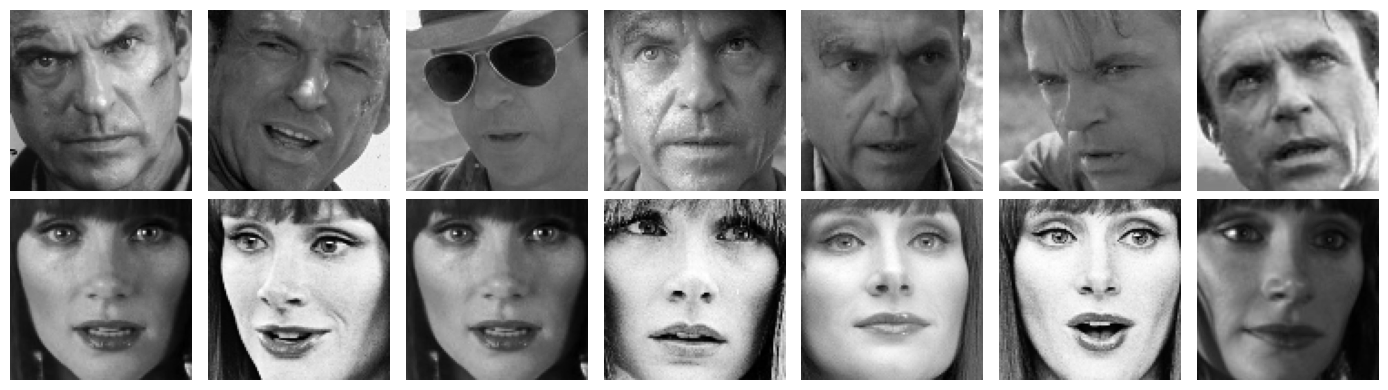

In [2]:
#Configuration des détecteurs
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import dlib
import numpy as np
import cv2

hog_detector = dlib.get_frontal_face_detector()

def face_locations(image, model="hog"):
    detector = hog_detector
    cst = 0

    matches = detector(image, 1)
    rects = []

    for r in matches:
        x = max(r.left(), 0)
        y = max(r.top(), 0)
        w = min(r.right(), image.shape[1]) - x + cst
        h = min(r.bottom(), image.shape[0]) - y + cst
        rects.append((x, y, w, h))

    return rects

def extract_faces(image, model="hog"):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    rects = face_locations(gray, model)
    faces = []

    for (x,y,w,h) in rects:
        cropped = gray[y:y+h, x:x+w]
        cropped = cv2.resize(cropped, (100, 100))
        faces.append(cropped)

    return faces

def show_grid(faces, figsize=(12,3)):
    n = len(faces)
    cols = 7
    rows = int(np.ceil(n/cols))

    if rows == 1 and n <= cols:
        fig, ax = plt.subplots(1, n, figsize=figsize)
        for i in range(n):
            ax[i].imshow(faces[i], cmap='gray')
            ax[i].axis('off')
    else:
        fig, ax = plt.subplots(rows, cols, figsize=figsize)
        for r in range(rows):
            for c in range(cols):
                i = r*cols + c
                if i < n:
                    if rows == 1:
                        ax[c].imshow(faces[i], cmap='gray')
                        ax[c].axis('off')
                    else:
                        ax[r,c].imshow(faces[i], cmap='gray')
                        ax[r,c].axis('off')
                elif rows > 1:
                    ax[r,c].axis('off')

    plt.tight_layout()
    plt.show()
    
def list_images(basePath, validExts=(".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
    imagePaths = []

    for root, dirs, files in os.walk(basePath):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in validExts:
                imagePath = os.path.join(root, file)
                imagePaths.append(imagePath)

    return imagePaths

#Chemin vers le dossier de données
data_path = '/kaggle/input/datatp7/data'

#Extraire les visages et les étiquettes
all_faces = []
all_labels = []

#Parcourir chaque dossier de personne
for person_folder in sorted(os.listdir(data_path)):
    person_path = os.path.join(data_path, person_folder)

    if os.path.isdir(person_path):
        person_name = person_folder
        image_paths = list_images(person_path)

        for img_path in image_paths:
            img = cv2.imread(img_path)

            if img is not None:
                faces = extract_faces(img, model="hog")

                if faces:
                    face = faces[0]
                    all_faces.append(face)
                    all_labels.append(person_name)

#Convertir en tableaux NumPy
all_faces = np.array(all_faces)
all_labels = np.array(all_labels)

# Vérifier le type et la taille des images dans all_faces
print(type(all_faces))  # Cela vous donnera le type de l'objet, qui devrait être un tableau NumPy
print(all_faces.shape)  # Cela vous donne la forme de chaque image (dimensions)
print(all_faces[0].dtype)  # Cela vous donne le type de données de chaque image (par exemple uint8)
print("Nombre d'images:", all_faces.shape[0])



#Visualiser quelques visages
if len(all_faces) > 0:
    show_grid(all_faces[:min(14, len(all_faces))], figsize=(14, 4))

#Sauvegarder avec pickle
with open('faces_data.pickle', 'wb') as f:
    pickle.dump((all_faces, all_labels), f)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2714 - loss: 2.2447 - val_accuracy: 0.2000 - val_loss: 1.7705
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1946 - loss: 1.7662 - val_accuracy: 0.2600 - val_loss: 1.6747
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3201 - loss: 1.5944 - val_accuracy: 0.4000 - val_loss: 1.5759
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4170 - loss: 1.5492 - val_accuracy: 0.4400 - val_loss: 1.4697
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4517 - loss: 1.4006 - val_accuracy: 0.4600 - val_loss: 1.3328
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5167 - loss: 1.2441 - val_accuracy: 0.5200 - val_loss: 1.2343
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5506 - loss: 1.1662 - val_accuracy: 0.5400 - val_loss: 1.1151
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6206 - loss: 1.0225 - val_accuracy: 0.6000 - val_loss: 1.0565
Ep

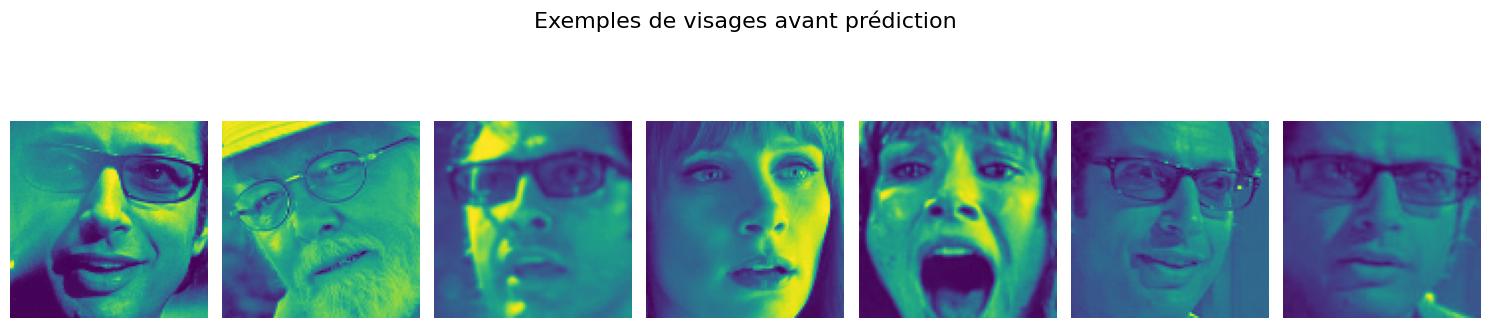

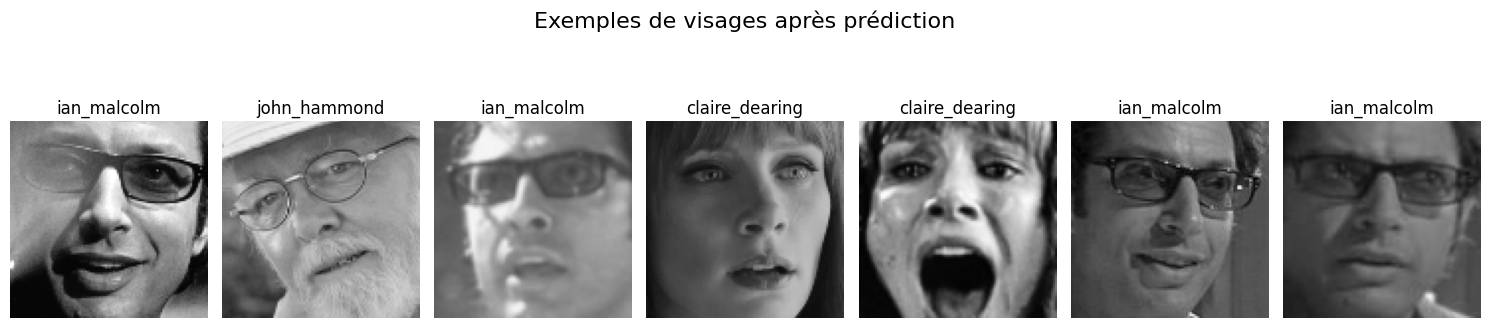

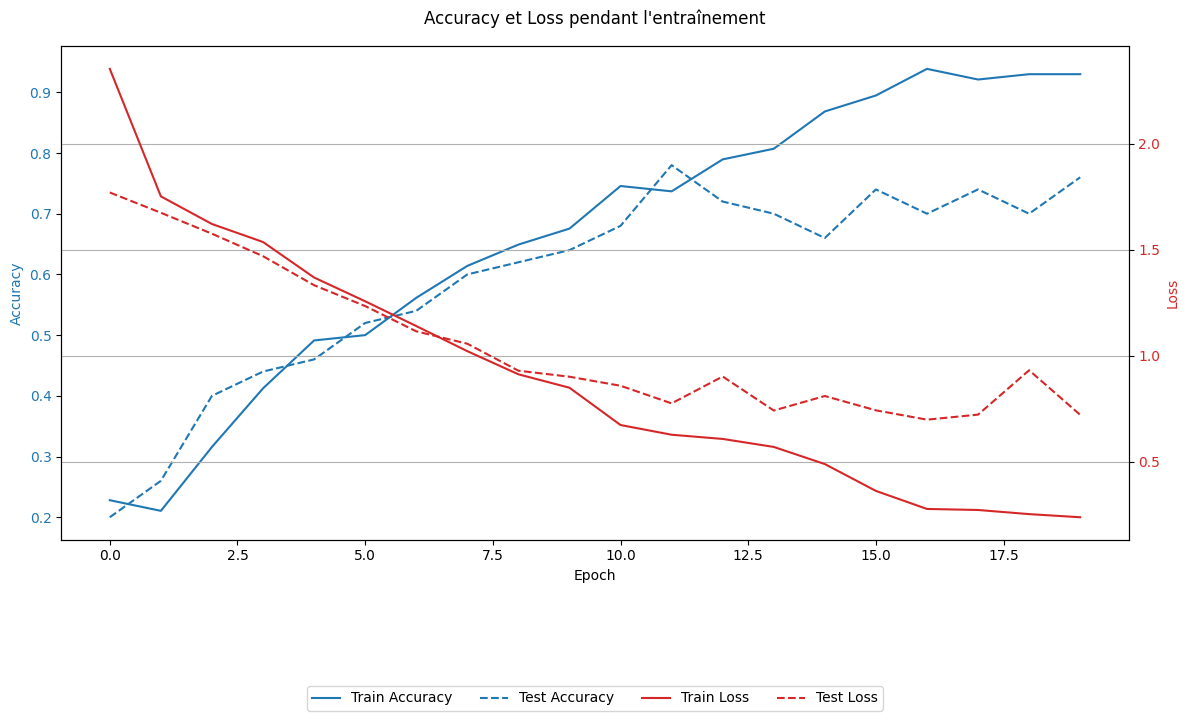

In [3]:
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Chargement des données
with open('faces_data.pickle', 'rb') as f:
    faces, labels = pickle.load(f)

# Normalisation des visages (division par 255)
faces_normalized = faces.astype('float32') / 255.0

faces_normalized = np.expand_dims(faces_normalized, axis=-1)

# Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    faces_normalized, labels, test_size=0.3, random_state=42, stratify=labels
)


# Encodage des labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Transformation en one-hot
y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

model = Sequential([
    Input(shape=(faces_normalized.shape[1], faces_normalized.shape[2], faces_normalized.shape[3])),  # dynamique
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(y_train_enc)), activation='softmax')  # output = nb classes
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32
)

# Évaluation du modèle sur le test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

# Affichage de l'accuracy en pourcentage
print(f"Accuracy sur le jeu de test : {test_accuracy * 100:.2f}%")

#Visage avant prédiction
plt.figure(figsize=(15, 4))
for i in range(7):
    plt.subplot(1, 7, i+1)
    plt.imshow(X_test[i])
    plt.axis('off') 
plt.suptitle("Exemples de visages avant prédiction", fontsize=16)
plt.tight_layout()
plt.show()

# Visualiser quelques exemples prédict
plt.figure(figsize=(15, 4))
for i in range(min(7, len(X_test))):
    plt.subplot(1, 7, i+1)
    plt.imshow(X_test[i], cmap='gray', vmin=0, vmax=1)
    label_idx = np.argmax(y_test_cat[i])
    label_name = le.inverse_transform([label_idx])[0]
    plt.title(label_name)
    plt.axis('off')
plt.suptitle("Exemples de visages après prédiction", fontsize=16)
plt.tight_layout()
plt.show()

# Fusion des deux courbes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axe de gauche pour l'accuracy
color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy', color=color)
ax1.plot(history.history['accuracy'], label='Train Accuracy', color=color, linestyle='-')
ax1.plot(history.history['val_accuracy'], label='Test Accuracy', color=color, linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

# Axe de droite pour la loss
ax2 = ax1.twinx()  # partage le même axe X
color = 'tab:red'
ax2.set_ylabel('Loss', color=color)
ax2.plot(history.history['loss'], label='Train Loss', color=color, linestyle='-')
ax2.plot(history.history['val_loss'], label='Test Loss', color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Titre et légende
fig.suptitle('Accuracy et Loss pendant l\'entraînement')
fig.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=4)
fig.tight_layout()
plt.grid(True)
plt.show()

# Sauvegarder les ensembles d'entraînement et de test
with open('train_test_data.pickle', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)


#### Provided functions

Here you will find some useful functions to complete the assignment.

In [ ]:
#!wget https://perso.esiee.fr/~najmanl/FaceRecognition/models.zip
#!unzip models.zip

In [ ]:
hog_detector = dlib.get_frontal_face_detector()
#cnn_detector = dlib.cnn_face_detection_model_v1('/kaggle/input/modelstp7/models/mmod_human_face_detector.dat')

def face_locations(image, model="hog"):

    if model == "hog":
        detector = hog_detector
        cst = 0
    elif model == "cnn":
        detector = cnn_detector
        cst = 10

    matches = detector(image,1)
    rects   = []

    for r in matches:
        if model == "cnn":
            r = r.rect
        x = max(r.left(), 0)
        y = max(r.top(), 0)
        w = min(r.right(), image.shape[1]) - x + cst
        h = min(r.bottom(), image.shape[0]) - y + cst
        rects.append((x,y,w,h))

    return rects

In [ ]:
def extract_faces(image, model="hog"):

    gray  = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    rects = face_locations(gray, model)
    faces = []

    for (x,y,w,h) in rects:
        cropped = image[y:y+h, x:x+w, :]
        cropped = cv2.resize(cropped, (128,128))
        faces.append(cropped)

    return faces

In [ ]:
def show_grid(faces, figsize=(12,3)):

    n = len(faces)
    cols = 7
    rows = int(np.ceil(n/cols))

    fig, ax = plt.subplots(rows,cols, figsize=figsize)

    for r in range(rows):
        for c in range(cols):
            i = r*cols + c
            if i == n:
                 break
            ax[r,c].imshow(faces[i])
            ax[r,c].axis('off')
            #ax[r,c].set_title('size: ' + str(faces[i].shape[:2]))

In [ ]:
def list_images(basePath, validExts=(".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"), contains=None):

    imagePaths = []

    # loop over the directory structure
    for (rootDir, dirNames, filenames) in os.walk(basePath):
        # loop over the filenames in the current directory
        for filename in filenames:
            # if the contains string is not none and the filename does not contain
            # the supplied string, then ignore the file
            if contains is not None and filename.find(contains) == -1:
                continue

            # determine the file extension of the current file
            ext = filename[filename.rfind("."):].lower()

            # check to see if the file is an image and should be processed
            if ext.endswith(validExts):
                # construct the path to the image and yield it
                imagePath = os.path.join(rootDir, filename).replace(" ", "\\ ")
                imagePaths.append(imagePath)

    return imagePaths

#### Hints

The provided function `extract_faces()` applies face detection to a single input image, and returns a list of 128x128 blocks containing the detected faces.

In [ ]:
#!wget https://perso.esiee.fr/~najmanl/FaceRecognition/figures.zip
#!unzip figures.zip

In [ ]:
image = cv2.imread("/kaggle/input/figures/figures/faces.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
plt.figure(figsize=(15,5))
plt.imshow(image)

In [ ]:
faces = extract_faces(image, "hog")  # Replace 'cnn' with 'hog' for faster but less accurate results

In [ ]:
show_grid(faces)

Moreover, the function `list_images()` locates all the jpeg/png/tiff files in a given folder (including its subfolders).

In [ ]:
#!wget https://perso.esiee.fr/~najmanl/FaceRecognition/data.zip
#!unzip data.zip

In [ ]:
imagePaths = list_images("/kaggle/input/datatp7/data")
imagePaths

## 2. Pose estimation

You have isolated the faces in our image. But now you have to deal with the problem that faces turned different directions look totally different to a computer. To account for this, you will try to warp each picture so that the eyes and lips are always in the same place in the image. More concretely, you are going to use an algorithm called face landmark estimation. The basic idea is to locate 68 specific points (called landmarks) that exist on every face:  the top of the chin, the outside edge of each eye, the inner edge of each eyebrow, etc. Then, you’ll simply rotate, scale and shear the image so that the eyes and mouth are centered as best as possible. This will make face recognition more accurate.

<img src="https://perso.esiee.fr/~najmanl/FaceRecognition/figures/pose.png" style="height:200px;">

### Assignment

Here's what you are required to do for this part of the assignment.

- Further preprocess the face pictures by correcting their pose. You should now have a dataset of cropped, aligned, and normalized faces.


- Re-train your convnets on the modified dataset.


- Evaluate the performance on the test set, and compare it to the scores obtained with your previously trained convnets.

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2525 - loss: 1.7872 - val_accuracy: 0.2600 - val_loss: 1.6081
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3514 - loss: 1.5581 - val_accuracy: 0.4200 - val_loss: 1.5261
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4547 - loss: 1.4194 - val_accuracy: 0.4600 - val_loss: 1.3641
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5825 - loss: 1.1369 - val_accuracy: 0.5400 - val_loss: 1.2308
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6366 - loss: 1.0018 - val_accuracy: 0.6000 - val_loss: 1.1294
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6851 - loss: 0.8758 - val_accuracy: 0.5600 - val_loss: 1.0688
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7379 - loss: 0.7974 - val_accuracy: 0.7200 - val_loss: 0.8806
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7525 - loss: 0.6912 - val_accuracy: 0.6200 - val_loss: 0.8847
Ep

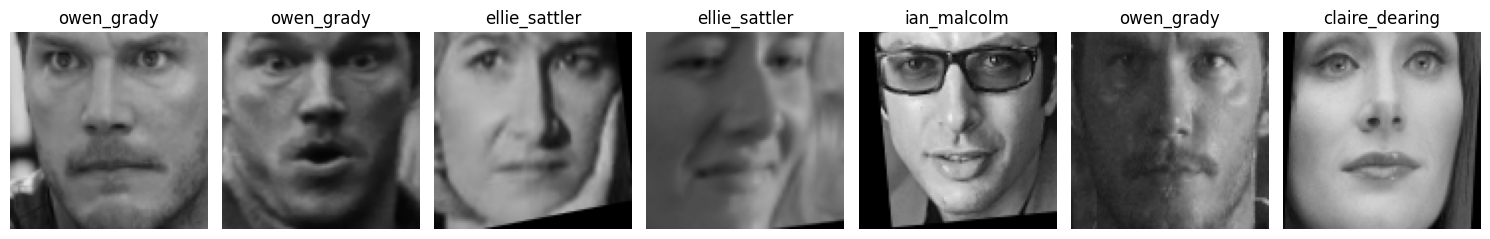

Comparaison des performances :
- Sans alignement : 76.00%
- Avec alignement : 80.00%


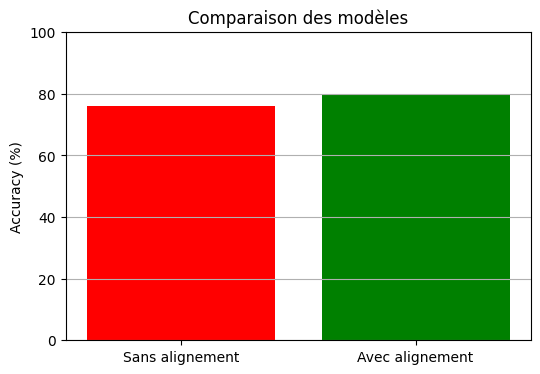

In [4]:
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import dlib
import numpy as np
import cv2

# Modèles de repères faciaux
pose68 = dlib.shape_predictor('/kaggle/input/modelstp7/models/shape_predictor_68_face_landmarks.dat')

def face_landmarks(face, model="large"):
    predictor = pose68 if model == "large" else pose05
    if not isinstance(face, list):
        rect = dlib.rectangle(0, 0, face.shape[1], face.shape[0])
        return predictor(face, rect)
    else:
        rect = dlib.rectangle(0, 0, face[0].shape[1], face[0].shape[0])
        return [predictor(f, rect) for f in face]

def shape_to_coords(shape):
    return np.float32([[p.x, p.y] for p in shape.parts()])

TEMPLATE = np.float32([
    (0.0792396913815, 0.339223741112), (0.0829219487236, 0.456955367943),
    (0.0967927109165, 0.575648016728), (0.122141515615, 0.691921601066),
    (0.168687863544, 0.800341263616), (0.239789390707, 0.895732504778),
    (0.325662452515, 0.977068762493), (0.422318282013, 1.04329000149),
    (0.531777802068, 1.06080371126), (0.641296298053, 1.03981924107),
    (0.738105872266, 0.972268833998), (0.824444363295, 0.889624082279),
    (0.894792677532, 0.792494155836), (0.939395486253, 0.681546643421),
    (0.96111933829, 0.562238253072), (0.970579841181, 0.441758925744),
    (0.971193274221, 0.322118743967), (0.163846223133, 0.249151738053),
    (0.21780354657, 0.204255863861), (0.291299351124, 0.192367318323),
    (0.367460241458, 0.203582210627), (0.4392945113, 0.233135599851),
    (0.586445962425, 0.228141644834), (0.660152671635, 0.195923841854),
    (0.737466449096, 0.182360984545), (0.813236546239, 0.192828009114),
    (0.8707571886, 0.235293377042), (0.51534533827, 0.31863546193),
    (0.516221448289, 0.396200446263), (0.517118861835, 0.473797687758),
    (0.51816430343, 0.553157797772), (0.433701156035, 0.604054457668),
    (0.475501237769, 0.62076344024), (0.520712933176, 0.634268222208),
    (0.565874114041, 0.618796581487), (0.607054002672, 0.60157671656),
    (0.252418718401, 0.331052263829), (0.298663015648, 0.302646354002),
    (0.355749724218, 0.303020650651), (0.403718978315, 0.33867711083),
    (0.352507175597, 0.349987615384), (0.296791759886, 0.350478978225),
    (0.631326076346, 0.334136672344), (0.679073381078, 0.29645404267),
    (0.73597236153, 0.294721285802), (0.782865376271, 0.321305281656),
    (0.740312274764, 0.341849376713), (0.68499850091, 0.343734332172),
    (0.353167761422, 0.746189164237), (0.414587777921, 0.719053835073),
    (0.477677654595, 0.706835892494), (0.522732900812, 0.717092275768),
    (0.569832064287, 0.705414478982), (0.635195811927, 0.71565572516),
    (0.69951672331, 0.739419187253), (0.639447159575, 0.805236879972),
    (0.576410514055, 0.835436670169), (0.525398405766, 0.841706377792),
    (0.47641545769, 0.837505914975), (0.41379548902, 0.810045601727),
    (0.380084785646, 0.749979603086), (0.477955996282, 0.74513234612),
    (0.523389793327, 0.748924302636), (0.571057789237, 0.74332894691),
    (0.672409137852, 0.744177032192), (0.572539621444, 0.776609286626),
    (0.5240106503, 0.783370783245), (0.477561227414, 0.778476346951)])
TPL_MIN, TPL_MAX = np.min(TEMPLATE, axis=0), np.max(TEMPLATE, axis=0)
MINMAX_TEMPLATE = (TEMPLATE - TPL_MIN) / (TPL_MAX - TPL_MIN)
INNER_EYES_AND_BOTTOM_LIP = np.array([39, 42, 57])

def align_faces(images, landmarks, idx=INNER_EYES_AND_BOTTOM_LIP):
    faces = []
    for (img, marks) in zip(images, landmarks):
        imgDim = img.shape[0]
        coords = shape_to_coords(marks)
        H = cv2.getAffineTransform(coords[idx], imgDim * MINMAX_TEMPLATE[idx])
        warped = cv2.warpAffine(img, H, (imgDim, imgDim))
        faces.append(warped)
    return np.array(faces)

# Chargement des données
with open('faces_data.pickle', 'rb') as f:
    faces, labels = pickle.load(f)

# Normalisation
faces_normalized = faces.astype('float32') / 255.0

# Alignement des visages
landmarks = face_landmarks(list(faces))  # landmarks doivent être basés sur les images NON normalisées
aligned_faces = align_faces(faces_normalized, landmarks)
aligned_faces = aligned_faces[..., np.newaxis]  # Ajoute une dimension pour les canaux


# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    aligned_faces, labels, test_size=0.3, random_state=42, stratify=labels
)

# Encodage des labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Transformation en one-hot
y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

model = Sequential([
    Input(shape=(aligned_faces.shape[1], aligned_faces.shape[2], aligned_faces.shape[3])),  # dynamique
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(y_train_enc)), activation='softmax')  # output = nb classes
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32
)

# Évaluation du modèle sur le test set
test_loss, test_accuracy_align = model.evaluate(X_test, y_test_cat, verbose=0)


# Affichage de l'accuracy en pourcentage
print(f"Accuracy sur le jeu de test : {test_accuracy_align * 100:.2f}%")

# Visualisation
plt.figure(figsize=(15, 4))
for i in range(min(7, len(X_train))):
    plt.subplot(1, 7, i + 1)
    plt.imshow(X_train[i], cmap='gray', vmin=0, vmax=1)
    plt.title(y_train[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

acc_sans_alignement = test_accuracy * 100
acc_avec_alignement = test_accuracy_align * 100 

# Affichage simple
print("Comparaison des performances :")
print(f"- Sans alignement : {acc_sans_alignement:.2f}%")
print(f"- Avec alignement : {acc_avec_alignement:.2f}%")

# Affichage graphique
plt.figure(figsize=(6,4))
plt.bar(['Sans alignement', 'Avec alignement'], [acc_sans_alignement, acc_avec_alignement], color=['red', 'green'])
plt.ylabel('Accuracy (%)')
plt.title('Comparaison des modèles')
plt.ylim(0, 100)
plt.grid(axis='y')
plt.show()

# Sauvegarde
with open('train_test_data.pickle', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)

#### Provided functions

Here you will find some useful functions to complete the assignment.

In [ ]:
pose68 = dlib.shape_predictor('/kaggle/input/modelstp7/models/shape_predictor_68_face_landmarks.dat')
pose05 = dlib.shape_predictor('/kaggle/input/modelstp7/models/shape_predictor_5_face_landmarks.dat')

def face_landmarks(face, model="large"):

    if model == "large":
        predictor = pose68
    elif model == "small":
        predictor = pose05

    if not isinstance(face, list):
        rect = dlib.rectangle(0,0,face.shape[1],face.shape[0])
        return predictor(face, rect)
    else:
        rect = dlib.rectangle(0,0,face[0].shape[1],face[0].shape[0])
        return [predictor(f,rect) for f in face]

In [ ]:
def shape_to_coords(shape):
    return np.float32([[p.x, p.y] for p in shape.parts()])

In [ ]:
TEMPLATE = np.float32([
    (0.0792396913815, 0.339223741112), (0.0829219487236, 0.456955367943),
    (0.0967927109165, 0.575648016728), (0.122141515615, 0.691921601066),
    (0.168687863544, 0.800341263616), (0.239789390707, 0.895732504778),
    (0.325662452515, 0.977068762493), (0.422318282013, 1.04329000149),
    (0.531777802068, 1.06080371126), (0.641296298053, 1.03981924107),
    (0.738105872266, 0.972268833998), (0.824444363295, 0.889624082279),
    (0.894792677532, 0.792494155836), (0.939395486253, 0.681546643421),
    (0.96111933829, 0.562238253072), (0.970579841181, 0.441758925744),
    (0.971193274221, 0.322118743967), (0.163846223133, 0.249151738053),
    (0.21780354657, 0.204255863861), (0.291299351124, 0.192367318323),
    (0.367460241458, 0.203582210627), (0.4392945113, 0.233135599851),
    (0.586445962425, 0.228141644834), (0.660152671635, 0.195923841854),
    (0.737466449096, 0.182360984545), (0.813236546239, 0.192828009114),
    (0.8707571886, 0.235293377042), (0.51534533827, 0.31863546193),
    (0.516221448289, 0.396200446263), (0.517118861835, 0.473797687758),
    (0.51816430343, 0.553157797772), (0.433701156035, 0.604054457668),
    (0.475501237769, 0.62076344024), (0.520712933176, 0.634268222208),
    (0.565874114041, 0.618796581487), (0.607054002672, 0.60157671656),
    (0.252418718401, 0.331052263829), (0.298663015648, 0.302646354002),
    (0.355749724218, 0.303020650651), (0.403718978315, 0.33867711083),
    (0.352507175597, 0.349987615384), (0.296791759886, 0.350478978225),
    (0.631326076346, 0.334136672344), (0.679073381078, 0.29645404267),
    (0.73597236153, 0.294721285802), (0.782865376271, 0.321305281656),
    (0.740312274764, 0.341849376713), (0.68499850091, 0.343734332172),
    (0.353167761422, 0.746189164237), (0.414587777921, 0.719053835073),
    (0.477677654595, 0.706835892494), (0.522732900812, 0.717092275768),
    (0.569832064287, 0.705414478982), (0.635195811927, 0.71565572516),
    (0.69951672331, 0.739419187253), (0.639447159575, 0.805236879972),
    (0.576410514055, 0.835436670169), (0.525398405766, 0.841706377792),
    (0.47641545769, 0.837505914975), (0.41379548902, 0.810045601727),
    (0.380084785646, 0.749979603086), (0.477955996282, 0.74513234612),
    (0.523389793327, 0.748924302636), (0.571057789237, 0.74332894691),
    (0.672409137852, 0.744177032192), (0.572539621444, 0.776609286626),
    (0.5240106503, 0.783370783245), (0.477561227414, 0.778476346951)])

TPL_MIN, TPL_MAX = np.min(TEMPLATE, axis=0), np.max(TEMPLATE, axis=0)
MINMAX_TEMPLATE = (TEMPLATE - TPL_MIN) / (TPL_MAX - TPL_MIN)

INNER_EYES_AND_BOTTOM_LIP = np.array([39, 42, 57])
OUTER_EYES_AND_NOSE = np.array([36, 45, 33])

In [ ]:
def align_faces(images, landmarks, idx=INNER_EYES_AND_BOTTOM_LIP):
    faces = []
    for (img, marks) in zip(images, landmarks):
        imgDim = img.shape[0]
        coords = shape_to_coords(marks)
        H = cv2.getAffineTransform(coords[idx], imgDim * MINMAX_TEMPLATE[idx])
        warped = cv2.warpAffine(img, H, (imgDim, imgDim))
        faces.append(warped)
    return faces

#### Hints

The provided function `face_landmarks()` computes the landmarks for a list of cropped faces.

In [ ]:
landmarks = face_landmarks(faces)

In [ ]:
new_faces = []
for (face,shape) in zip(faces, landmarks):
    canvas = face.copy()
    coords = shape_to_coords(shape)
    for p in coords:
        cv2.circle(canvas, (int(p[0]),int(p[1])), 1, (0, 0, 255), -1)
    new_faces.append(canvas)

In [ ]:
show_grid(new_faces, figsize=(15,5))

In [ ]:
aligned = align_faces(faces, landmarks)

In [ ]:
show_grid(aligned, figsize=(15,5))

In [ ]:
plt.imshow( np.stack(aligned, axis=3).astype(np.float32).mean(axis=3)/255 )

## 3. Face encoding

The simplest approach to face recognition is to directly classify an unknown face with a convnet trained on your database of tagged people. Seems like a pretty good idea, right? There’s actually a huge problem with that approach. A site like Facebook with billions of users and a trillion photos can’t possibly train such a big convnet. That would take way too long. What you need is a way to extract a few basic measurements from each face, which you can then use to quickly compare the unknown face with your database. For example, you might measure the size of each ear, the spacing between the eyes, the length of the nose, etc. However, it turns out that the measurements that seem obvious to us humans (like eye color) don’t really make sense to a computer looking at individual pixels in an image. Researchers have discovered that the most accurate approach is to let the computer figure out the measurements to collect itself. Deep learning does a better job than humans at figuring out which parts of a face are important to measure.

The solution is to train a convnet. But instead of training the network to classify pictures, it is trained to generate 128 measurements for each face. The training process works by looking at 3 face images at a time: the picture of a known person, another picture of the same known person, and a picture of a totally different person. Then, the algorithm looks at the measurements currently generated for each of those three images. It tweaks the neural network slightly to make sure that the measurements generated for the same person are slightly closer, and the measurements for different persons are slightly further apart. After repeating this step millions of times for millions of images of thousands of different people, the convnet learns to generate 128 measurements for each person.

<img src="https://perso.esiee.fr/~najmanl/FaceRecognition/figures/triplet.png" style="height:400px;">

This process of training a convnet to output face encodings requires a lot of data and computer power. Even with an expensive GPU, it takes about 24 hours of continuous training to get good accuracy. But once the network has been trained, it can generate measurements for any face, even ones it has never seen before! So this step only needs to be done once. Fortunately, the people at [OpenFace](https://cmusatyalab.github.io/openface/) already did this and they published several trained networks which you can directly use. So all you need to do is run your face images through their pre-trained network to get the 128 measurements for each face.

<img src="https://perso.esiee.fr/~najmanl/FaceRecognition/figures/encoding.png" style="height:300px;">

### Assignment

Here's what you are required to do for this part of the assignment.

- Preprocess the cropped faces by encoding them. You should now have a dataset of cropped and encoded faces.


- Train a neural network on the modified dataset. Since the encoded faces are just 128-length vectors, **you don't need a convnet**. Use a regular neural network with a series of fully-connected layers.


- Evaluate the performance on the test set, and compare it to the scores obtained with your previously trained convnets.

Taille de X_train: (114, 128)
Taille de X_test: (50, 128)
Taille de y_train: (114,)
Taille de y_test: (50,)
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 692ms/step - accuracy: 0.1956 - loss: 1.7677 - val_accuracy: 0.3400 - val_loss: 1.6997
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4059 - loss: 1.6790 - val_accuracy: 0.3600 - val_loss: 1.6301
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3703 - loss: 1.6032 - val_accuracy: 0.3600 - val_loss: 1.5709
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4064 - loss: 1.5586 - val_accuracy: 0.4800 - val_loss: 1.5092
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6002 - loss: 1.4794 - val_accuracy: 0.6200 - val_loss: 1.4434
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6845 - loss: 1.4176 - val_accuracy: 0.6200 - val_loss: 1.3762
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6669 - loss: 1.3359 - val_accuracy: 0.7400 - val_loss: 1.3071
Epoch 8/20
4/4 ━━━━

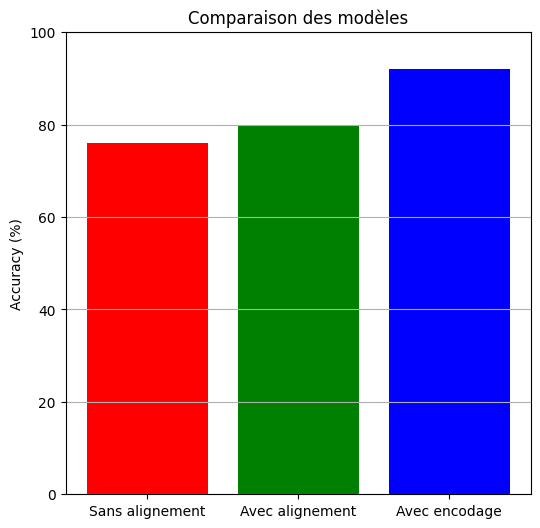

In [5]:
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import dlib
import numpy as np
import cv2

# Modèles de repères faciaux
pose68 = dlib.shape_predictor('/kaggle/input/modelstp7/models/shape_predictor_68_face_landmarks.dat')

def face_landmarks(face, model="large"):
    predictor = pose68 if model == "large" else pose05
    if not isinstance(face, list):
        rect = dlib.rectangle(0, 0, face.shape[1], face.shape[0])
        return predictor(face, rect)
    else:
        rect = dlib.rectangle(0, 0, face[0].shape[1], face[0].shape[0])
        return [predictor(f, rect) for f in face]

def shape_to_coords(shape):
    return np.float32([[p.x, p.y] for p in shape.parts()])

TEMPLATE = np.float32([
    (0.0792396913815, 0.339223741112), (0.0829219487236, 0.456955367943),
    (0.0967927109165, 0.575648016728), (0.122141515615, 0.691921601066),
    (0.168687863544, 0.800341263616), (0.239789390707, 0.895732504778),
    (0.325662452515, 0.977068762493), (0.422318282013, 1.04329000149),
    (0.531777802068, 1.06080371126), (0.641296298053, 1.03981924107),
    (0.738105872266, 0.972268833998), (0.824444363295, 0.889624082279),
    (0.894792677532, 0.792494155836), (0.939395486253, 0.681546643421),
    (0.96111933829, 0.562238253072), (0.970579841181, 0.441758925744),
    (0.971193274221, 0.322118743967), (0.163846223133, 0.249151738053),
    (0.21780354657, 0.204255863861), (0.291299351124, 0.192367318323),
    (0.367460241458, 0.203582210627), (0.4392945113, 0.233135599851),
    (0.586445962425, 0.228141644834), (0.660152671635, 0.195923841854),
    (0.737466449096, 0.182360984545), (0.813236546239, 0.192828009114),
    (0.8707571886, 0.235293377042), (0.51534533827, 0.31863546193),
    (0.516221448289, 0.396200446263), (0.517118861835, 0.473797687758),
    (0.51816430343, 0.553157797772), (0.433701156035, 0.604054457668),
    (0.475501237769, 0.62076344024), (0.520712933176, 0.634268222208),
    (0.565874114041, 0.618796581487), (0.607054002672, 0.60157671656),
    (0.252418718401, 0.331052263829), (0.298663015648, 0.302646354002),
    (0.355749724218, 0.303020650651), (0.403718978315, 0.33867711083),
    (0.352507175597, 0.349987615384), (0.296791759886, 0.350478978225),
    (0.631326076346, 0.334136672344), (0.679073381078, 0.29645404267),
    (0.73597236153, 0.294721285802), (0.782865376271, 0.321305281656),
    (0.740312274764, 0.341849376713), (0.68499850091, 0.343734332172),
    (0.353167761422, 0.746189164237), (0.414587777921, 0.719053835073),
    (0.477677654595, 0.706835892494), (0.522732900812, 0.717092275768),
    (0.569832064287, 0.705414478982), (0.635195811927, 0.71565572516),
    (0.69951672331, 0.739419187253), (0.639447159575, 0.805236879972),
    (0.576410514055, 0.835436670169), (0.525398405766, 0.841706377792),
    (0.47641545769, 0.837505914975), (0.41379548902, 0.810045601727),
    (0.380084785646, 0.749979603086), (0.477955996282, 0.74513234612),
    (0.523389793327, 0.748924302636), (0.571057789237, 0.74332894691),
    (0.672409137852, 0.744177032192), (0.572539621444, 0.776609286626),
    (0.5240106503, 0.783370783245), (0.477561227414, 0.778476346951)])
TPL_MIN, TPL_MAX = np.min(TEMPLATE, axis=0), np.max(TEMPLATE, axis=0)
MINMAX_TEMPLATE = (TEMPLATE - TPL_MIN) / (TPL_MAX - TPL_MIN)
INNER_EYES_AND_BOTTOM_LIP = np.array([39, 42, 57])

# Chargement des données
with open('faces_data.pickle', 'rb') as f:
    faces, labels = pickle.load(f)

# Chargement des modèles
predictor_path = "/kaggle/input/modelstp7/models/shape_predictor_5_face_landmarks.dat"
face_rec_model_path = "/kaggle/input/modelstp7/models/dlib_face_recognition_resnet_model_v1.dat"

pose_predictor_5 = dlib.shape_predictor(predictor_path)
face_encoder = dlib.face_recognition_model_v1(face_rec_model_path)

# Fonction pour convertir une image OpenCV en RGB (dlib attend du RGB)
def convert_to_rgb(image):
    if len(image.shape) == 2:  # grayscale
        return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Fonction d'encodage des visages
def encode_faces(faces):
    encodings = []
    for face in faces:
        img_rgb = convert_to_rgb(face)
        rect = dlib.rectangle(0, 0, img_rgb.shape[1], img_rgb.shape[0])
        landmarks = pose_predictor_5(img_rgb, rect)
        encoding = face_encoder.compute_face_descriptor(img_rgb, landmarks)
        encodings.append(np.array(encoding))
    return encodings

# Charger les visages extraits précédemment
with open('faces_data.pickle', 'rb') as f:
    all_faces, all_labels = pickle.load(f)

# Encoder tous les visages
encoded_faces = encode_faces(all_faces)

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    encoded_faces, labels, test_size=0.3, random_state=42, stratify=labels
)

# Conversion en numpy array
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test=np.array(y_test)

# Vérification des tailles
print("Taille de X_train:", X_train.shape)
print("Taille de X_test:", X_test.shape)
print("Taille de y_train:", y_train.shape)
print("Taille de y_test:", y_test.shape)


# Encodage des labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Transformation en one-hot
y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

model = Sequential([
    Input(shape=(128,)),  # Entrée explicite avec forme (128,)
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(X_train, y_train_cat, epochs=20, batch_size=32, validation_data=(X_test, y_test_cat))


# Évaluation du modèle sur le test set
test_loss, test_accuracy_enc = model.evaluate(X_test, y_test_cat, verbose=0)


# Affichage de l'accuracy en pourcentage
print(f"Accuracy sur le jeu de test : {test_accuracy_enc * 100:.2f}%")

acc_avec_encodage = test_accuracy_enc*100

# Affichage simple
print("Comparaison des performances :")
print(f"- Sans alignement : {acc_sans_alignement:.2f}%")
print(f"- Avec alignement : {acc_avec_alignement:.2f}%")
print(f"- Avec encodage : {acc_avec_encodage:.2f}%")

# Affichage graphique
plt.figure(figsize=(6,6))
plt.bar(['Sans alignement', 'Avec alignement', 'Avec encodage'], [acc_sans_alignement, acc_avec_alignement, acc_avec_encodage], color=['red', 'green','blue'])
plt.ylabel('Accuracy (%)')
plt.title('Comparaison des modèles')
plt.ylim(0, 100)
plt.grid(axis='y')
plt.show()

# Sauvegarde
with open('train_test_data.pickle', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)

#### Provided functions

In [ ]:
cnn_encoder = dlib.face_recognition_model_v1('/kaggle/input/modelstp7/models/dlib_face_recognition_resnet_model_v1.dat')

def face_encoder(faces):

    landmarks = face_landmarks(faces)

    if not isinstance(faces, list):
        return np.array(cnn_encoder.compute_face_descriptor(faces,landmarks))
    else:
        return np.array([cnn_encoder.compute_face_descriptor(f,l) for f,l in zip(faces,landmarks)])

#### Hints

The provided function `face_encoder()` computes the encodings for a list of cropped faces. Alignment and normalization are handled internally.

In [ ]:
encoded_faces = face_encoder(faces)

In [ ]:
plt.plot(encoded_faces[0])

## 4. Face recognition

This last step is actually the easiest one in the whole process. All you have to do is find the person in your database of known people who has the closest measurements to some test image. You can do that by using any machine learning classification algorithm, such as neaural network (as you did in the previous section), logistic regression, SVM, nearest neighbours, etc. All you need to do is training a classifier that can take in the measurements from a new test image, and tells which known person is the closest match. Running this classifier must only take milliseconds, so that you can apply it to video sequences.

<img src="https://perso.esiee.fr/~najmanl/FaceRecognition/figures/test.gif" style="height:300px;">

### Assignment

Here's what you are required to do for this part of the assignment.

-  Train several classifiers (logistic regression, SVM, kNN, neural network) on the dataset of encoded faces (you can use the package `scikit-learn`).

- Evaluate their performance on the test set, in terms of accuracy and speed.

- Finally, run your best classifier on the test images and video available in the `test` folder.

In [41]:
import pickle
import time
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import os
import cv2

In [6]:
# Define classifier
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear', probability=True),
    "kNN": KNeighborsClassifier(),
    "Neural Network": MLPClassifier(max_iter=1000)
}

def train_and_evaluate(classifiers, X_train, X_test, y_train, y_test):
    results = {}
    for name, clf in classifiers.items():
        print(f"Training {name}...")
        start_train = time.time()
        clf.fit(X_train, y_train)
        end_train = time.time()

        # Make predictions
        start_pred = time.time()
        y_pred = clf.predict(X_test)
        end_pred = time.time()

        accuracy = accuracy_score(y_test, y_pred)
        training_time = end_train - start_train
        prediction_time = end_pred - start_pred

        results[name] = {
            'accuracy': accuracy,
            'training_time': training_time,
            'prediction_time': prediction_time
        }

    return results


In [7]:
# Train classifiers and evaluate performance
results = train_and_evaluate(classifiers, X_train, X_test, y_train, y_test)

# Display results
for name, result in results.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {result['accuracy'] * 100:.2f}%")
    print(f"  Training Time: {result['training_time']:.2f}s")
    print(f"  Prediction Time: {result['prediction_time']:.2f}s")

Training Logistic Regression...
Training SVM...
Training kNN...
Training Neural Network...

Logistic Regression:
  Accuracy: 92.00%
  Training Time: 0.02s
  Prediction Time: 0.00s

SVM:
  Accuracy: 100.00%
  Training Time: 0.01s
  Prediction Time: 0.00s

kNN:
  Accuracy: 100.00%
  Training Time: 0.00s
  Prediction Time: 0.04s

Neural Network:
  Accuracy: 98.00%
  Training Time: 0.43s
  Prediction Time: 0.00s


In [8]:
import pickle
import time
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Chargement des données
with open('train_test_data.pickle', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

# Entraînement du modèle SVM
svm_model = SVC(kernel='linear', probability=True)  # `probability=True` si tu veux des scores de confiance
start_train = time.time()
svm_model.fit(X_train, y_train)
end_train = time.time()

# Évaluation
start_pred = time.time()
y_pred = svm_model.predict(X_test)
end_pred = time.time()

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Temps entraînement : {end_train - start_train:.2f}s")
print(f"Temps prédiction : {end_pred - start_pred:.2f}s")

#Sauvegarde du modèle
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

print("Modèle SVM sauvegardé dans 'svm_model.pkl'")

Accuracy : 100.00%
Temps entraînement : 0.01s
Temps prédiction : 0.00s
Modèle SVM sauvegardé dans 'svm_model.pkl'


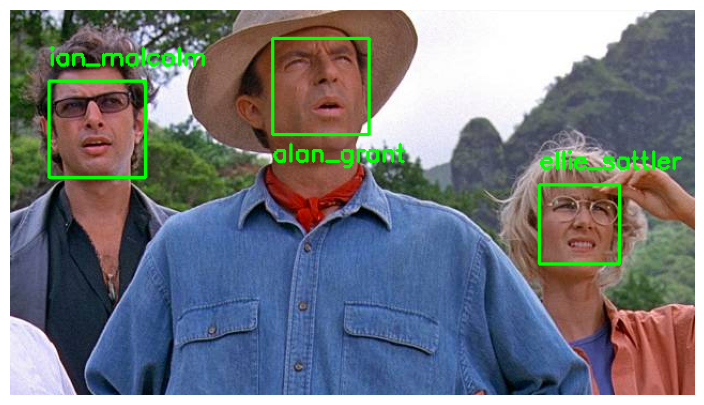

In [11]:
import pickle
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt

# Charger le modèle SVM
with open('svm_model.pkl', 'rb') as f:
    svm_model = pickle.load(f)


cnn_encoder = dlib.face_recognition_model_v1('/kaggle/input/modelstp7/models/dlib_face_recognition_resnet_model_v1.dat')

def process_frame(image, mode="fast"):

    # face detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if mode == "fast":
        matches = hog_detector(gray,1)
    else:
        matches = cnn_detector(gray,1)
        matches = [m.rect for m in matches]

    for rect in matches:

        # face landmarks
        landmarks = pose68(gray, rect)

        # face encoding
        encoding = cnn_encoder.compute_face_descriptor(image, landmarks)

        # face classification
        label = svm_model.predict([encoding])[0]

        # draw box
        cv2.rectangle(image, (rect.left(), rect.top()), (rect.right(), rect.bottom()), (0, 255, 0), 2)
        y = rect.top() - 15 if rect.top() - 15 > 15 else rect.bottom() + 25
        cv2.putText(image, label, (rect.left(), y), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)

    return image

def process_movie(video_name, outvideo_name='/kaggle/working/videoResult2.mp4', mode="fast"):

    print(video_name)
    video  = cv2.VideoCapture(video_name)
    if (video.isOpened()== False): 
        print("Error opening video stream or file")
        return
    
    frame_width = int(video.get(3))
    frame_height = int(video.get(4))
    print("dimension de la video")
    print(frame_width, frame_height)
    size = (int(frame_width/2),int(frame_height/2))
    print(size)
    out_mp4 = cv2.VideoWriter(outvideo_name,cv2.VideoWriter_fourcc(*'XVID'), 10, size)


    while video.isOpened():

        # Grab a single frame of video
        ret, frame = video.read()
        if ret == True:
            # Resize frame of video for faster processing
            frame = cv2.resize(frame, (0, 0), fx=0.5, fy=0.5)
            # Process frame
            image = process_frame(frame, mode)
            # Write the processed frame to output video
            out_mp4.write(image)
        else:
            break
    # Release video
    video.release()
    out_mp4.release()
    print("Video released")

# Exemple d'appel à la fonction sur une image
image = cv2.imread('/kaggle/input/testtp7/test/example_03.png')
processed_image = process_frame(image)

# Convertir l'image de BGR (OpenCV) en RGB (matplotlib)
processed_image_rgb = cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB)

# Affichage de l'image avec matplotlib
plt.figure(figsize=(15, 5))
plt.imshow(processed_image_rgb)
plt.axis('off')  # Pour enlever les axes
plt.show()


In [ ]:
def process_movie(video_name, outvideo_name='/kaggle/working/videoResult2.mp4', mode="fast"):

    print(video_name)
    video  = cv2.VideoCapture(video_name)
    if (video.isOpened()== False): 
        print("Error opening video stream or file")
        return
    
    frame_width = int(video.get(3))
    frame_height = int(video.get(4))
    print("dimension de la video")
    print(frame_width, frame_height)
    size = (int(frame_width/2),int(frame_height/2))
    print(size)
    out_mp4 = cv2.VideoWriter(outvideo_name,cv2.VideoWriter_fourcc(*'XVID'), 10, size)


    while video.isOpened():

        # Grab a single frame of video
        ret, frame = video.read()
        if ret == True:
            # Resize frame of video for faster processing
            frame = cv2.resize(frame, (0, 0), fx=0.5, fy=0.5)
            # Process frame
            image = process_frame(frame, mode)
            # Write the processed frame to output video
            out_mp4.write(image)
        else:
            break
    # Release video
    video.release()
    out_mp4.release()
    print("Video released")

process_movie("/kaggle/input/testtp7/test/lunch_scene.mp4")

#### Provided functions

In [46]:
def process_frame(image, mode="fast"):

    # face detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if mode == "fast":
        matches = hog_detector(gray,1)
    else:
        matches = cnn_detector(gray,1)
        matches = [m.rect for m in matches]

    for rect in matches:

        # face landmarks
        landmarks = pose68(gray, rect)

        # face encoding
        encoding = cnn_encoder.compute_face_descriptor(image, landmarks)

        # face classification
        label = "label"

        # draw box
        cv2.rectangle(image, (rect.left(), rect.top()), (rect.right(), rect.bottom()), (0, 255, 0), 2)
        y = rect.top() - 15 if rect.top() - 15 > 15 else rect.bottom() + 25
        cv2.putText(image, label, (rect.left(), y), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)

    return image

**Note:** cv2.VideoCapture does not work in Google Colab. You can use https://colab.research.google.com/notebooks/snippets/advanced_outputs.ipynb#scrollTo=2viqYx97hPMi to capture video 'on the fly' with Google Colab. The following function has to be modified accordingly

In [47]:
def process_movie(video_name, outvideo_name='/kaggle/working/videoResult2.mp4', mode="fast"):

    print(video_name)
    video  = cv2.VideoCapture(video_name)
    if (video.isOpened()== False): 
        print("Error opening video stream or file")
        return
    
    frame_width = int(video.get(3))
    frame_height = int(video.get(4))
    print("dimension de la video")
    print(frame_width, frame_height)
    size = (int(frame_width/2),int(frame_height/2))
    print(size)
    out_mp4 = cv2.VideoWriter(outvideo_name,cv2.VideoWriter_fourcc(*'XVID'), 10, size)


    while video.isOpened():

        # Grab a single frame of video
        ret, frame = video.read()
        if ret == True:
            # Resize frame of video for faster processing
            frame = cv2.resize(frame, (0, 0), fx=0.5, fy=0.5)
            # Process frame
            image = process_frame(frame, mode)
            # Write the processed frame to output video
            out_mp4.write(image)
        else:
            break
    # Release video
    video.release()
    out_mp4.release()
    print("Video released")

from IPython.display import HTML
HTML("""
<video width=1024 controls>
  <source src="/kaggle/input/testtp7/test/lunch_scene.mp4" type="video/mp4">
</video>
""")

#### Hints

The provided function `process_frame()` detects and encodes all the faces in the input image.

In [ ]:
#!wget https://perso.esiee.fr/~najmanl/FaceRecognition/test.zip
#!unzip test.zip

In [ ]:
image = cv2.imread("/kaggle/input/testtp7/test/example_03.png")

In [ ]:
processed = process_frame(image.copy())
processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

In [ ]:
plt.figure(figsize=(15,5))
plt.imshow(processed)

The provided function `process_frame()` detects and encodes the faces in the input video.

In [ ]:
process_movie("/kaggle/input/testtp7/test/lunch_scene.mp4")

The special input `0` can be used to access the webcam.

In [ ]:
process_movie(0)

## 5. Build a custom dataset

So far, you have used a pre-curated dataset, where somebody did the hard work of gathering and labeling the images for you. Now, you will tackle the problem of recognizing faces of yourselves, friends, family members, colleagues, etc. To accomplish this, you need to gather examples of faces you want to recognize. You can enroll facial pictures via a webcam attached to your computer.

### Assignment
Here's what you are required to do for this part of the assignment.

- Use your webcam to enroll face pictures of yourself, your friends, etc. To do so, you need to open the webcam, detect faces in the video stream, and save the captured face images to disk.


- Build a dataset of reasonable size: a group of 10-15 people with 50-100 face pictures each, taken in different conditions of light, angle, emotion, etc.


- Apply the previously developed pipeline to build your own personalized face recognition system.

In [12]:
#Code utilisé dans VSCODE pou extraire 100 images par vidéo

import cv2
import os
import sys

def extract_frames(video_path, output_folder, num_frames=100):
    # Ouvre la vidéo
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Erreur : Impossible d'ouvrir la vidéo {video_path}")
        return

    # Récupère le nombre total de frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Nombre total d'images dans la vidéo : {total_frames}")

    # Calcule l'intervalle entre les frames à sauvegarder
    interval = max(total_frames // num_frames, 1)

    # Crée le dossier de sortie s'il n'existe pas
    os.makedirs(output_folder, exist_ok=True)

    frame_idx = 0
    saved_count = 0

    while cap.isOpened() and saved_count < num_frames:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % interval == 0:
            # Chemin de sauvegarde
            frame_name = f"{saved_count:04d}.jpg"
            frame_path = os.path.join(output_folder, frame_name)
            cv2.imwrite(frame_path, frame)
            saved_count += 1

        frame_idx += 1

    cap.release()
    print(f"Extraction terminée : {saved_count} images sauvegardées dans '{output_folder}'.")

if __name__ == "__main__":
    if len(sys.argv) != 3:
        print("Utilisation : python extract_frames.py <chemin_video.MOV> <nom_personne>")
        sys.exit(1)

    video_path = sys.argv[1]
    person_name = sys.argv[2]

    extract_frames(video_path, person_name)


Erreur : Impossible d'ouvrir la vidéo -f


Pas de visage détecté pour l'image /kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/personne/Clement/0074.jpg
Pas de visage détecté pour l'image /kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/personne/Clement/0077.jpg
Pas de visage détecté pour l'image /kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/personne/Clement/0078.jpg
Pas de visage détecté pour l'image /kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/personne/Clement/0082.jpg
Pas de visage détecté pour l'image /kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/personne/Clement/0076.jpg
Pas de visage détecté pour l'image /kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/personne/Clement/0079.jpg
Pas de visage détecté pour l'image /kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/personne/Clement/0075.jpg
Pas de visage détect

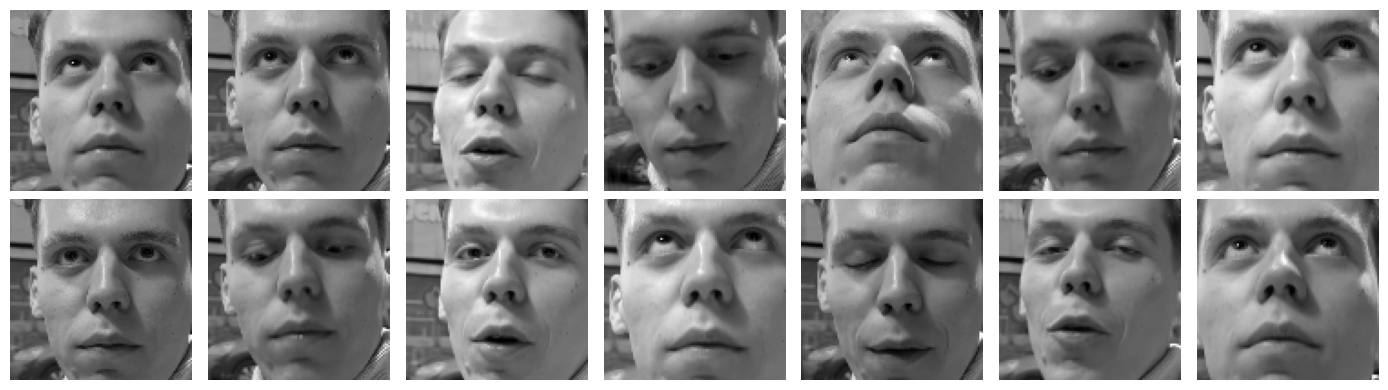

In [13]:
import os
import cv2
import numpy as np
import pickle

# Chemin vers le dossier de données
data_path = '/kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/personne'

# Extraire les visages et les étiquettes
all_faces = []
all_labels = []

# Parcourir chaque dossier de personne
for person_folder in sorted(os.listdir(data_path)):
    person_path = os.path.join(data_path, person_folder)

    if os.path.isdir(person_path):
        person_name = person_folder  # Utiliser le nom du dossier comme label
        image_paths = list_images(person_path)  # Liste des images dans ce dossier

        for img_path in image_paths:
            img = cv2.imread(img_path)

            if img is not None:
                faces = extract_faces(img, model="hog")

                # Vérifier s'il y a des visages détectés
                if faces:
                    for face in faces:  # Si plusieurs visages sont détectés, on peut les traiter
                        all_faces.append(face)  # Ajouter le visage extrait
                        all_labels.append(person_name)  # Ajouter le label (nom de la personne)
                else:
                    print(f"Pas de visage détecté pour l'image {img_path}")

# Convertir en tableaux NumPy
all_faces = np.array(all_faces)
all_labels = np.array(all_labels)

# Vérifier la taille des données
print(f"Taille de all_faces: {all_faces.shape}")
print(f"Taille de all_labels: {all_labels.shape}")

# Visualiser quelques visages
if len(all_faces) > 0:
    show_grid(all_faces[:min(14, len(all_faces))], figsize=(14, 4))

# Sauvegarder avec pickle
with open('faces_data.pickle', 'wb') as f:
    pickle.dump((all_faces, all_labels), f)

In [14]:
# Chargement des modèles
predictor_path = "/kaggle/input/modelstp7/models/shape_predictor_5_face_landmarks.dat"
face_rec_model_path = "/kaggle/input/modelstp7/models/dlib_face_recognition_resnet_model_v1.dat"

pose_predictor_5 = dlib.shape_predictor(predictor_path)
face_encoder = dlib.face_recognition_model_v1(face_rec_model_path)

# Fonction pour convertir une image OpenCV en RGB (dlib attend du RGB)
def convert_to_rgb(image):
    if len(image.shape) == 2:  # grayscale
        return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Fonction d'encodage des visages
def encode_faces(faces):
    encodings = []
    for face in faces:
        img_rgb = convert_to_rgb(face)
        rect = dlib.rectangle(0, 0, img_rgb.shape[1], img_rgb.shape[0])
        landmarks = pose_predictor_5(img_rgb, rect)
        encoding = face_encoder.compute_face_descriptor(img_rgb, landmarks)
        encodings.append(np.array(encoding))
    return encodings
# Charger les visages extraits précédemment
with open('faces_data.pickle', 'rb') as f:
    all_faces, all_labels = pickle.load(f)

# Encoder tous les visages
encoded_faces = encode_faces(all_faces)

# Vérifier que les tailles sont cohérentes
print("Taille de encoded_faces:", len(encoded_faces))  # Devrait être égal à len(all_faces)
print("Taille de all_labels:", len(all_labels))  # Devrait être égal à len(all_faces)

# Afficher quelques exemples de chaque pour vérifier la correspondance
print("Exemples de visages encodés:", encoded_faces[:5])  # Affiche les 5 premiers visages encodés
print("Exemples de labels:", all_labels[:5])  # Affiche les 5 premiers labels

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    encoded_faces, all_labels, test_size=0.3, random_state=42, stratify=all_labels
)

# Sauvegarde
with open('train_test_data.pickle', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)

Taille de encoded_faces: 693
Taille de all_labels: 693
Exemples de visages encodés: [array([-7.05271661e-02,  9.30919573e-02, -5.44224754e-02,  9.44680125e-02,
       -2.60510296e-02, -3.95197719e-02, -1.52009036e-02, -1.19727120e-01,
        1.58665687e-01, -4.67297956e-02,  2.84276009e-01, -4.61848676e-02,
       -2.63736963e-01, -6.50316030e-02,  3.26503664e-02,  1.00478090e-01,
       -1.10036127e-01, -2.58456022e-02, -1.42743170e-01, -3.60641032e-02,
        1.22173630e-01,  6.54970258e-02,  1.21036753e-01,  4.08007801e-02,
       -1.75706923e-01, -2.55707175e-01, -1.35812089e-01, -1.30799159e-01,
        4.79376316e-02, -9.87037420e-02, -6.27285987e-03,  1.72605067e-02,
       -1.80464536e-01, -8.48963037e-02,  1.42150521e-02,  1.10981762e-02,
       -1.13058910e-01, -7.14771226e-02,  2.35807002e-01,  2.08653510e-05,
       -1.58059612e-01, -1.77733600e-02, -4.15172055e-02,  2.41302907e-01,
        1.59297168e-01,  1.66063979e-02,  2.10653935e-02, -7.26859868e-02,
        6.53450

In [15]:
import pickle
import time
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Chargement des données
with open('train_test_data.pickle', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

# Vérifier les tailles des données
print("Taille de X_train:", len(X_train))
print("Taille de X_test:", len(X_test))
print("Taille de y_train:", len(y_train))
print("Taille de y_test:", len(y_test))

# Vérifier la cohérence des tailles
if len(X_train) != len(y_train):
    raise ValueError(f"Nombre d'échantillons dans X_train ({len(X_train)}) et y_train ({len(y_train)}) ne correspond pas!")
if len(X_test) != len(y_test):
    raise ValueError(f"Nombre d'échantillons dans X_test ({len(X_test)}) et y_test ({len(y_test)}) ne correspond pas!")

# Entraînement du modèle SVM
svm_model = SVC(kernel='linear', probability=True)  # `probability=True` si tu veux des scores de confiance
start_train = time.time()
svm_model.fit(X_train, y_train)
end_train = time.time()

# Évaluation
start_pred = time.time()
y_pred = svm_model.predict(X_test)
end_pred = time.time()

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Temps entraînement : {end_train - start_train:.2f}s")
print(f"Temps prédiction : {end_pred - start_pred:.2f}s")

# Sauvegarde du modèle
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

print("Modèle SVM sauvegardé dans 'svm_model.pkl'")

Taille de X_train: 485
Taille de X_test: 208
Taille de y_train: 485
Taille de y_test: 208
Accuracy : 100.00%
Temps entraînement : 0.05s
Temps prédiction : 0.00s
Modèle SVM sauvegardé dans 'svm_model.pkl'


In [16]:
def process_frame(image, mode="fast"):

    # face detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if mode == "fast":
        matches = hog_detector(gray,1)
    else:
        matches = cnn_detector(gray,1)
        matches = [m.rect for m in matches]

    for rect in matches:

        # face landmarks
        landmarks = pose68(gray, rect)

        # face encoding
        encoding = cnn_encoder.compute_face_descriptor(image, landmarks)

        # face classification
        label = svm_model.predict([encoding])[0]

        # draw box
        cv2.rectangle(image, (rect.left(), rect.top()), (rect.right(), rect.bottom()), (0, 255, 0), 2)
        y = rect.top() - 15 if rect.top() - 15 > 15 else rect.bottom() + 25
        cv2.putText(image, label, (rect.left(), y), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)

    return image

def process_movie(video_name, outvideo_name='/kaggle/working/videoResult2.mp4', mode="fast"):

    print(video_name)
    video  = cv2.VideoCapture(video_name)
    if (video.isOpened()== False): 
        print("Error opening video stream or file")
        return
    
    frame_width = int(video.get(3))
    frame_height = int(video.get(4))
    print("dimension de la video")
    print(frame_width, frame_height)
    size = (int(frame_width/2),int(frame_height/2))
    print(size)
    out_mp4 = cv2.VideoWriter(outvideo_name,cv2.VideoWriter_fourcc(*'XVID'), 10, size)


    while video.isOpened():

        # Grab a single frame of video
        ret, frame = video.read()
        if ret == True:
            # Resize frame of video for faster processing
            frame = cv2.resize(frame, (0, 0), fx=0.5, fy=0.5)
            # Process frame
            image = process_frame(frame, mode)
            # Write the processed frame to output video
            out_mp4.write(image)
        else:
            break
    # Release video
    video.release()
    out_mp4.release()
    print("Video released")

In [ ]:
process_movie("/kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/test/Kahina_test.mov", outvideo_name='/kaggle/working/KahinaResult.mp4')

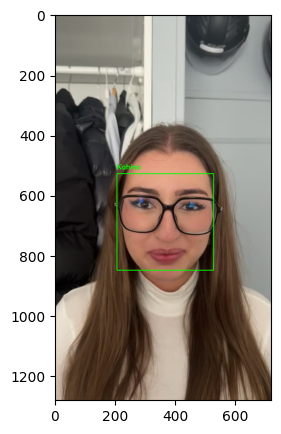

In [17]:
image_test_kahina = cv2.imread("/kaggle/input/database-perso/base de donnee projet ia/base de donnee projet ia/personne/Kahina/0001.jpg")
processed = process_frame(image_test_kahina.copy())
processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15,5))
plt.imshow(processed)

---
## Credits

This assignment is based on Adam Geitgey's [post](https://medium.com/@ageitgey/machine-learning-is-fun-part-4-modern-face-recognition-with-deep-learning-c3cffc121d78).

---